<a href="https://colab.research.google.com/github/seonilj/eeg-mne-pipeline/blob/main/notebooks/01_eeg_loading_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EEG Data Loading & Spatial Visualization using MNE-Python
## MNE-Python 기반 EEG 데이터 로딩 및 공간 시각화

---

# Goal

### 🇬🇧 English

This notebook demonstrates the first stage of an EEG analysis workflow using the PhysioNet EEG Motor Movement/Imagery dataset.

The objective is to load raw EEG recordings, standardize channel names, assign the international 'standard_1005' electrode montage, and visualize both electrode locations and raw EEG signals.

This notebook serves as the foundation for a motor imagery EEG analysis pipeline. The processed data prepared here will be used in later notebooks for signal preprocessing, feature extraction, and simple machine learning experiments.

### 🇰🇷 한국어

본 노트북은 PhysioNet EEG Motor Movement/Imagery Dataset을 이용하여 EEG 분석 파이프라인의 첫 단계를 구현합니다.

원시 EEG 데이터를 불러오고, 채널명을 표준화한 후, 국제 표준 'standard_1005' 전극 좌표계를 적용한 후 전극 위치와 원시 EEG 파형을 시각화하는 것이 목적입니다.

이 노트북은 운동 상상 EEG 분석 파이프라인의 기초가 됩니다. 여기서 준비된 처리된 데이터는 이후 노트북에서 신호 전처리, 특징 추출 및 간단한 머신러닝 실험에 사용될 것입니다.


---

# Workflow

### 🇬🇧 English

- Load raw EEG recordings
- Inspect recording metadata
- Standardize EEG channel names
- Apply the standard_1005 montage
- Visualize electrode locations
- Inspect raw EEG waveforms

### 🇰🇷 한국어

- 원시 EEG 데이터 불러오기
- 메타데이터 확인
- 채널명 표준화
- standard_1005 좌표계 적용
- 전극 위치 시각화
- 원시 EEG 파형 확인

---

# Expected Outcome

### 🇬🇧 English

By the end of this notebook, the EEG recording will be successfully standardized and anatomically mapped, providing a standardized dataset for the next preprocessing and feature extraction steps.

### 🇰🇷 한국어

노트북 실행이 완료되면 EEG 데이터가 표준화되고 국제 전극 좌표계에 매핑되고, 이후 전처리 및 특징 추출 단계를 위한 표준화된 데이터 세트를 제공합니다.

---

## Step 1: Environment Setup & Dependency Importation

In [ ]:
# ==============================================================================
# Step 1: Environment Setup & Dependency Importation
# ==============================================================================
# Install MNE-Python (Standard neuroimaging library) directly into the environment
%pip install mne matplotlib

import mne
import matplotlib.pyplot as plt
import numpy as np
import os

print("MNE-Python Version:", mne.__version__)
print("Environment ready. Proceed to the next step.")

MNE-Python Version: 1.12.1
Environment ready. Proceed to the next step.


## Step 2: Automated BCI Dataset Downloading (Source: PhysioNet)

In [ ]:
# ==============================================================================
# Step 2: Data Acquisition (EEGBCI Dataset)
# ==============================================================================
# Fetch Subject 1, Run 4 data (Motor Imagery task: Imagining left/right hand movements)
subject = 1
runs = [4]

# Download data (Automatically cached locally; returns the absolute file path)
raw_fnames = mne.datasets.eegbci.load_data(subject, runs)

# Load raw EEG data into an MNE Data Object
# Setting preload=True loads all signals into RAM for optimized processing speed
raw = mne.io.read_raw_edf(raw_fnames[0], preload=True)

print("\n - Data successfully loaded into memory! -")
print(raw)  # Displays structural metadata (channel count, sampling rate, duration, etc.)

Using default location ~/mne_data for EEGBCI...
Creating /root/mne_data


Do you want to set the path:
    /root/mne_data
as the default EEGBCI dataset path in the mne-python config [y]/n? y
Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 46s (2.5 MB)
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...

 - Data successfully loaded into memory! -
<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>


## Step 3: Verifying Metadata and Channel Specifications

In [ ]:
# ==============================================================================
# Step 3: Data Cleansing & Sensor Co-registration
# ==============================================================================

# 1. Strip trailing dots ('.') from PhysioNet electrode labels (Data Cleansing)
# e.g., standardizes 'C3..' or 'Fc5.' into clean identifiers like 'C3' and 'Fc5'
mapping = {ch_name: ch_name.rstrip('.') for ch_name in raw.ch_names}
raw.rename_channels(mapping)

# 2. Map the international standard 10-05 montage to support extended intermediate channels
# Disabling strict case matching (match_case=False) ensures robust mapping (e.g., 'Fc5' vs 'FC5')
montage = mne.channels.make_standard_montage('standard_1005')
raw.set_montage(montage, match_case=False)

# 3. Verify the channel renaming by inspecting the first 5 electrode labels
print("Cleaned Channel Samples (First 5):", raw.ch_names[:5])

# 4. Compute the total experimental recording time
duration = raw.n_times / raw.info['sfreq']
print(f"Total Recording Length: {duration} seconds (approx. {duration/60:.2f} minutes)")

Cleaned Channel Samples (First 5): ['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2']
Total Recording Length: 125.0 seconds (approx. 2.08 minutes)


## Step 4: Visualizing Raw (Unprocessed) EEG Signals

Created missing directory in Colab: ./figures
Successfully saved 'raw_eeg.png' into the Colab file system.


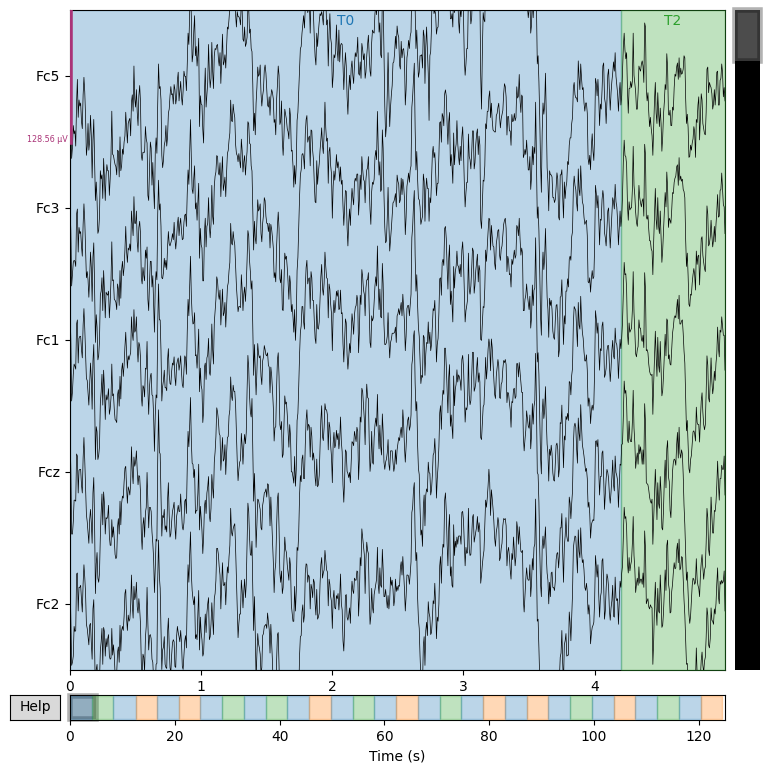

In [ ]:
# ==============================================================================
# Step 4: Time-Series Signal Visualization
# ==============================================================================
# Configure Matplotlib to render graphics inline within the notebook
%matplotlib inline

# Visualize the first 5 seconds of the top 5 EEG channels
# n_channels=5: Number of sensors to display, duration=5: Time window in seconds
fig = raw.plot(n_channels=5,
               duration=5,
               scalings='auto',
               show=False)

# --- [ Colab Environment Optimization ] Handle Output Directory Creation ---
# Code Colab operates relative to the './' or '/content/' directory.
output_dir = "./figures"

# Automatically generate the directory (if it's missing in this Colab session)
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created missing directory in Colab: {output_dir}")

# Save the figure 'raw_eeg.png'
fig.savefig(
    os.path.join(output_dir, "raw_eeg.png"),
    dpi=300,
    bbox_inches="tight"
)
print("Successfully saved 'raw_eeg.png' into the Colab file system.")

plt.show()

## Step 5: 2D Brain Sensor Topography Map

Successfully saved 'sensor_topomap.png' into the Colab file system.


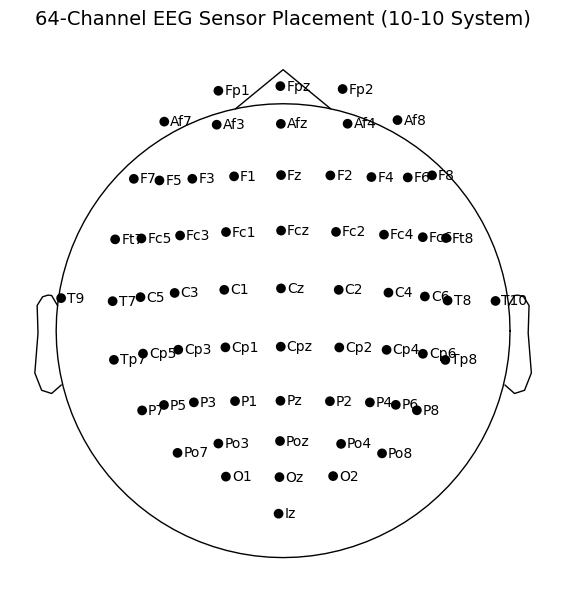

In [ ]:
# ==============================================================================
# Step 5: 2D Sensor Topography Mapping
# ==============================================================================

# Map the spatial arrangement of the 64-channel matrix on a 2D scalp surface

# Create a dedicated matplotlib figure object
fig, ax = plt.subplots(figsize=(6, 6))

# Execute standalone MNE visualization pipeline mapped directly onto the axes layout
# NOTE: Using raw.plot_sensors(kind='topomap', show_names=True, axes=ax) directly may cause overriding.
# Set show=False so it populates the canvas before rendering
mne.viz.plot_sensors(
    raw.info,
    kind='topomap',
    show_names=True,
    axes=ax,
    show=False
)

# Apply customized layout adjustments and titles
plt.title(
    "64-Channel EEG Sensor Placement (10-10 System)",
    fontsize=14,
    pad=15
)
plt.tight_layout()

# Reuse the same directory path established in Step 4
output_dir = "./figures"

# Save the figure 'sensor_topomap.png' into the existing folder
fig.savefig(
    os.path.join(output_dir, "sensor_topomap.png"),
    dpi=300,
    bbox_inches="tight"
)
print("Successfully saved 'sensor_topomap.png' into the Colab file system.")

# Force the notebook engine to display the fully populated canvas
plt.show()